In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/IRIS.csv')

In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [10]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [12]:
df.duplicated().sum()

np.int64(3)

In [13]:
df.shape

(150, 5)

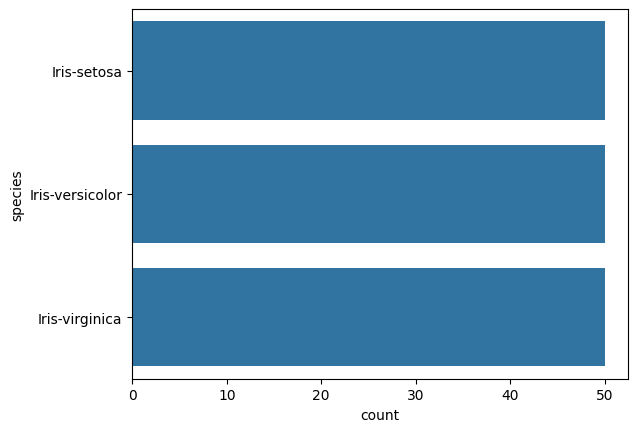

In [14]:
sns.countplot(df['species'])
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression


In [16]:
X = df.drop(columns=['species'])
y = df['species']



In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
Lr = LogisticRegression()
Lr.fit(X_train,y_train)
y_pred_lr = Lr.predict(X_test)
print(classification_report(y_test,y_pred_lr))


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [19]:
print(accuracy_score(y_test,y_pred_lr )*100)


100.0


In [20]:
print(confusion_matrix(y_test,y_pred_lr))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


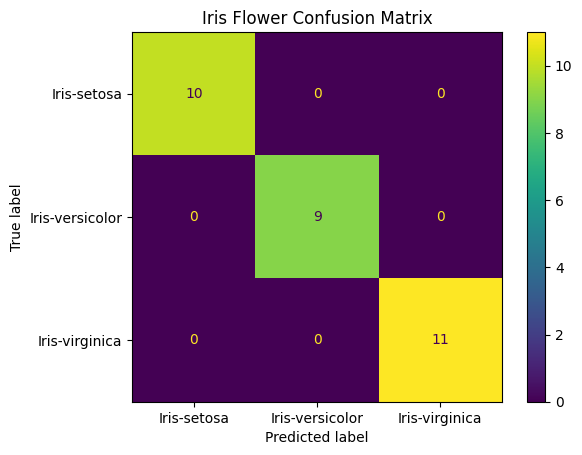

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

plt.title("Iris Flower Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
print(f1_score(y_test,y_pred_lr,average='weighted')*100)

100.0


In [ ]:
from google.colab import files
files.download('iris_model.pkl')

In [ ]:
import pickle
import os
from google.colab import files

with open('iris_model.pkl', 'wb') as file:
    pickle.dump(Lr, file)
    file.flush()
    os.fsync(file.fileno())

print("Succesfully Saved")

files.download('iris_model.pkl')
